In [1]:
from core.dataset import get_dataloaders
from src.models.efficientNet import get_efficient_net

from src.task_3_balancing.train_focal import run as run_focal
from src.task_3_balancing.train_adasyn import run as run_adasyn
from src.task_3_balancing.train_mixup import run as run_mixup

import torch
import torch.optim as optim

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

train_loader, val_loader = get_dataloaders(
    "../data/raw/train",
    "../data/raw/test"
)

def get_model():
    return get_efficient_net(num_classes=7).to(device)

def get_optimizer(model):
    return optim.AdamW(model.parameters(), lr=3e-4)

def get_scheduler(opt):
    return torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)


# =============================
# RUN ALL 3 STRATEGIES
# =============================

def run_strategy(name, run_fn):
    print(f"\n🔥 Running {name}")
    model = get_model()
    optimizer = get_optimizer(model)
    scheduler = get_scheduler(optimizer)
    run_fn(model, train_loader, val_loader, optimizer, scheduler, device)

run_strategy("FOCAL", run_focal)
run_strategy("MIXUP", run_mixup)
run_strategy("ADASYN", run_adasyn)


🔥 Running FOCAL
Strategy: focal
Model: efficientnet
Device: mps
Start Memory: 431.77 MB

Epoch 1/10
Train Loss: 0.8569
Train Acc: 48.59%
Val Acc:   61.48%
Macro F1:  0.5151
✅ New best model saved

Epoch 2/10
Train Loss: 0.6299
Train Acc: 59.55%
Val Acc:   64.61%
Macro F1:  0.5720
✅ New best model saved

Epoch 3/10
Train Loss: 0.5564
Train Acc: 62.79%
Val Acc:   66.65%
Macro F1:  0.6169
✅ New best model saved

Epoch 4/10
Train Loss: 0.5042
Train Acc: 65.37%
Val Acc:   67.58%
Macro F1:  0.6378
✅ New best model saved

Epoch 5/10
Train Loss: 0.4477
Train Acc: 68.14%
Val Acc:   68.31%
Macro F1:  0.6609
✅ New best model saved

Epoch 6/10
Train Loss: 0.4021
Train Acc: 70.57%
Val Acc:   68.78%
Macro F1:  0.6692
✅ New best model saved

Epoch 7/10
Train Loss: 0.3632
Train Acc: 72.25%
Val Acc:   69.39%
Macro F1:  0.6773
✅ New best model saved

Epoch 8/10
Train Loss: 0.3245
Train Acc: 74.54%
Val Acc:   70.38%
Macro F1:  0.6928
✅ New best model saved

Epoch 9/10
Train Loss: 0.3002
Train Acc: 75.91


🔍 Evaluating: FOCAL


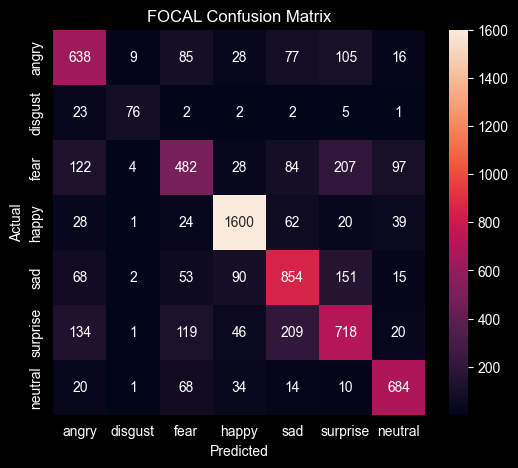


🔍 Evaluating: ADASYN


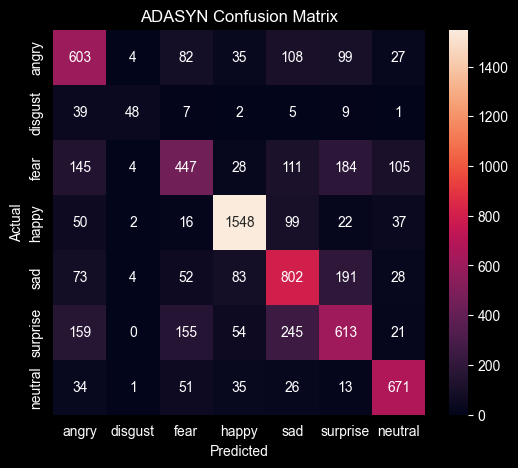


🔍 Evaluating: MIXUP


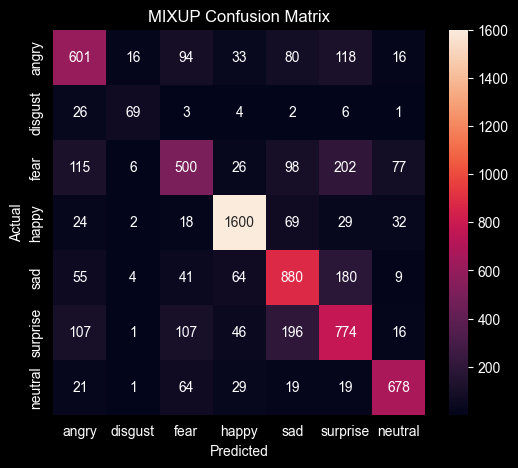


✅ Report saved to: /Users/bsama/Desktop/ds_interns_project_2_2026-Bhavya_Emotion_Recognition_from_Faces/emotion-recognition/results/balancing_comparison.md


In [5]:
import torch
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from src.models.efficientNet import get_efficient_net as get_model
from core.dataset import get_dataloaders

# =============================
# Setup
# =============================
PROJECT_ROOT = Path("../").resolve()
results_dir = PROJECT_ROOT / "results"
os.makedirs(results_dir, exist_ok=True)

class_names = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

_, val_loader = get_dataloaders(
    "../data/raw/train",
    "../data/raw/test"
)

# =============================
# Evaluate Function
# =============================
def evaluate_model(model, dataloader, device, class_names, strategy_name="model"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # =============================
    # Metrics
    # =============================
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True
    )

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    micro_f1 = f1_score(all_labels, all_preds, average="micro")

    minority_classes = ["disgust", "fear"]
    minority_f1 = np.mean([
        report[c]["f1-score"] for c in minority_classes if c in report
    ])

    # =============================
    # Confusion Matrix (DISPLAY ONLY)
    # =============================
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{strategy_name.upper()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # =============================
    # Save per-class metrics
    # =============================
    metrics_path = results_dir / f"{strategy_name}_per_class.txt"

    with open(metrics_path, "w") as f:
        f.write(f"=== {strategy_name.upper()} ===\n\n")

        for cls in class_names:
            f.write(f"{cls}:\n")
            f.write(f"  Precision: {report[cls]['precision']:.4f}\n")
            f.write(f"  Recall: {report[cls]['recall']:.4f}\n")
            f.write(f"  F1-score: {report[cls]['f1-score']:.4f}\n\n")

    return {
        "strategy": strategy_name,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "minority_f1": minority_f1
    }


# =============================
# Run Evaluation
# =============================
results = []

for strategy in ["focal", "adasyn", "mixup"]:
    print(f"\n🔍 Evaluating: {strategy.upper()}")

    model = get_model(num_classes=7)
    model.load_state_dict(
        torch.load(f"../results/checkpoints/{strategy}_best.pth", map_location=device)
    )
    model.to(device)

    res = evaluate_model(
        model,
        val_loader,
        device,
        class_names,
        strategy_name=strategy
    )

    results.append(res)


# =============================
# Generate Markdown Table
# =============================
md_path = results_dir / "balancing_comparison.md"

# Find best strategies
best_macro = max(results, key=lambda x: x["macro_f1"])
best_minority = max(results, key=lambda x: x["minority_f1"])

with open(md_path, "w") as f:
    f.write("# Model Comparison Report\n\n")

    # =============================
    # Overview
    # =============================
    f.write("## Overview\n")
    f.write(
        "This report compares three class imbalance handling strategies "
        "for emotion recognition:\n\n"
        "- Focal Loss\n"
        "- ADASYN Oversampling\n"
        "- Mixup Augmentation\n\n"
        "Evaluation is performed using Macro F1, Micro F1, and Minority F1 scores.\n\n"
    )

    # =============================
    # Results Table
    # =============================
    f.write("## Results\n\n")
    f.write("| Strategy | Macro F1 | Micro F1 | Minority F1 |\n")
    f.write("|----------|----------|----------|--------------|\n")

    for res in results:
        f.write(
            f"| {res['strategy']} "
            f"| {res['macro_f1']:.4f} "
            f"| {res['micro_f1']:.4f} "
            f"| {res['minority_f1']:.4f} |\n"
        )

    f.write("\n")

    # =============================
    # Analysis
    # =============================
    f.write("## Analysis\n\n")

    f.write(
        f"- **Best overall performance (Macro F1):** `{best_macro['strategy']}` "
        f"({best_macro['macro_f1']:.4f})\n"
    )

    f.write(
        f"- **Best minority class performance:** `{best_minority['strategy']}` "
        f"({best_minority['minority_f1']:.4f})\n\n"
    )

    f.write(
        "### Key Observations\n\n"
        "- Macro F1 reflects balanced performance across all classes.\n"
        "- Micro F1 is influenced by dominant classes.\n"
        "- Minority F1 highlights performance on underrepresented emotions.\n\n"
    )

    f.write(
        "### Conclusion\n\n"
        f"The `{best_macro['strategy']}` strategy provides the best overall balance across classes, "
        "while "
        f"`{best_minority['strategy']}` is more effective for handling minority classes. "
        "This demonstrates the trade-off between overall accuracy and minority class sensitivity.\n"
    )

print(f"\n✅ Report saved to: {md_path}")